In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import pandas as pd
df = pd.read_csv("/content/train.csv")

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df = df.drop('Id', axis=1)
df.head(3)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [ ]:
#แทนที่ค่าที่หายไปจาก col ที่เป็น ตัวเลขด้วย median
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col].fillna(df[col].median(), inplace=True)

df.head(3)

<ipython-input-37-9503b4ad9880>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [ ]:
# ใช้ One-Hot Encoding กับ categorical features
df = pd.get_dummies(df, drop_first=True).astype(int)
df.head(3)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65,8450,7,5,2003,2003,196,706,0,...,0,0,0,0,1,0,0,0,1,0
1,20,80,9600,6,8,1976,1976,0,978,0,...,0,0,0,0,1,0,0,0,1,0
2,60,68,11250,7,5,2001,2002,162,486,0,...,0,0,0,0,1,0,0,0,1,0


In [ ]:
# แยก Features และ Target (SalePrice)
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# แบ่งข้อมูล 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {"MAE": mae, "RMSE": rmse, "R2 Score": r2}

In [ ]:
# สร้างโมเดลต่างๆ
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=265,max_depth = 16, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

# ประเมินผลลัพธ์ของแต่ละโมเดล
results = {name: evaluate_model(model, X_train, X_test, y_train, y_test) for name, model in models.items()}

# แสดงผลลัพธ์
results_df = pd.DataFrame(results).T
print(results_df)

                            MAE          RMSE  R2 Score
Linear Regression  20485.454124  49257.876264  0.683672
Decision Tree      26066.934932  41121.907115  0.779539
Random Forest      17420.239922  28504.242654  0.894073
XGBoost            17507.628906  28180.963788  0.896462


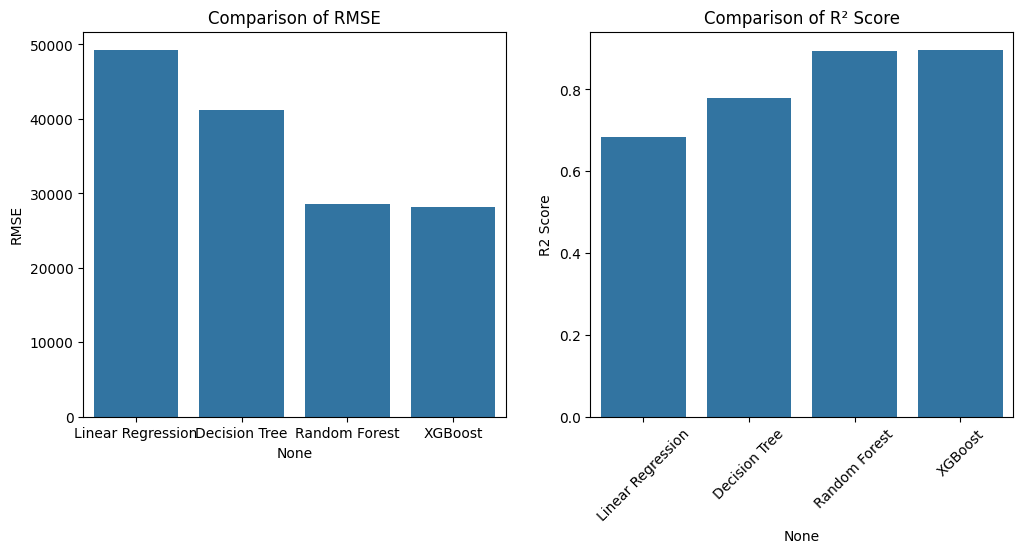

In [ ]:
### **6. วิเคราะห์ว่าทำไม Random Forest ถึงดีกว่า**
### **1. เปรียบเทียบค่า RMSE และ R²**
# แสดงกราฟเปรียบเทียบ
plt.figure(figsize=(12,5))

# RMSE
plt.subplot(1,2,1)
sns.barplot(x=results_df.index, y=results_df["RMSE"])
plt.title("Comparison of RMSE")

# R² Score
plt.subplot(1,2,2)
sns.barplot(x=results_df.index, y=results_df["R2 Score"])
plt.title("Comparison of R² Score")

plt.xticks(rotation=45)
plt.show()

การวิเคราะห์ Feature Importance:
เราสามารถเพิ่มการวิเคราะห์โดยดู Feature Importance จาก XGBoost model เพื่อเข้าใจว่าปัจจัยใดมีผลต่อราคาบ้านมากที่สุด

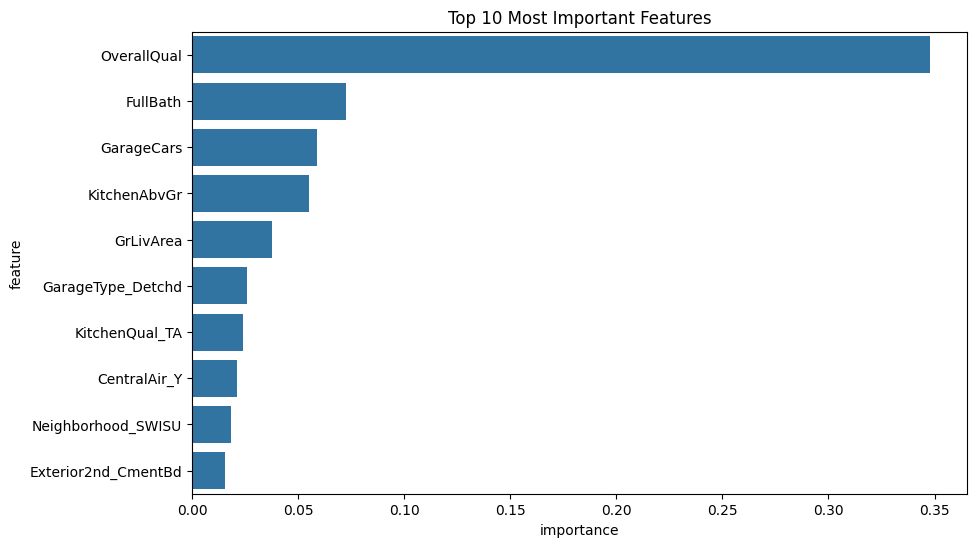

In [ ]:
rf_model = models["XGBoost"]
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Top 10 Most Important Features')
plt.show()

จากกราฟ Feature Importance ที่แสดง เราสามารถวิเคราะห์ปัจจัยที่มีผลต่อราคาบ้านได้ดังนี้:

1. คุณภาพโดยรวม (OverallQual) เป็นปัจจัยที่สำคัญที่สุดอย่างชัดเจน โดยมีความสำคัญประมาณ 35% ซึ่งสูงกว่าปัจจัยอื่นๆ มาก แสดงว่าคุณภาพการก่อสร้างและวัสดุโดยรวมมีผลต่อราคาบ้านมากที่สุด

2. กลุ่มปัจจัยรองลงมาที่มีความสำคัญใกล้เคียงกัน (ประมาณ 5-10%):
   - จำนวนห้องน้ำ (FullBath)
   - ขนาดโรงจอดรถ (GarageCars)
   - คุณภาพห้องครัว (KitchenAbvGr)
   - พื้นที่ห้องนั่งเล่น (GrLivArea)

3. ปัจจัยที่มีความสำคัญน้อยกว่า (ต่ำกว่า 5%):
   - ประเภทโรงจอดรถ (GarageType_Detchd)
   - คุณภาพห้องครัว (KitchenQual_TA)
   - ระบบปรับอากาศกลาง (CentralAir_Y)
   - ย่าน (Neighborhood_SWISU)
   - วัสดุภายนอก (Exterior2nd_CmentBd)

ข้อเสนอแนะสำหรับผู้ซื้อและผู้ขาย:
1. สำหรับผู้ขาย:
   - ควรให้ความสำคัญกับการปรับปรุงคุณภาพโดยรวมของบ้านเป็นอันดับแรก
   - การปรับปรุงห้องน้ำและโรงจอดรถอาจช่วยเพิ่มมูลค่าบ้านได้มาก
   - การปรับปรุงห้องครัวและพื้นที่ห้องนั่งเล่นก็มีความสำคัญ

2. สำหรับผู้ซื้อ:
   - ควรพิจารณาคุณภาพโดยรวมของบ้านเป็นหลัก เพราะมีผลต่อราคามากที่สุด
   - ตรวจสอบจำนวนและสภาพห้องน้ำ โรงจอดรถ และห้องครัวให้ดี
   - พื้นที่ใช้สอยโดยเฉพาะห้องนั่งเล่นมีผลต่อราคาพอสมควร

3. สำหรับนักพัฒนาอสังหาริมทรัพย์:
   - ควรลงทุนกับคุณภาพการก่อสร้างโดยรวมมากที่สุด
   - จัดสรรงบประมาณให้เหมาะสมกับการพัฒนาส่วนต่างๆ ตามลำดับความสำคัญ
   - อาจไม่จำเป็นต้องลงทุนมากกับปัจจัยที่มีความสำคัญน้อย เช่น วัสดุภายนอกบางประเภท

การวิเคราะห์ Prediction Errors:
เราสามารถดูว่าโมเดลทำนายผิดพลาดในกรณีใดบ้าง

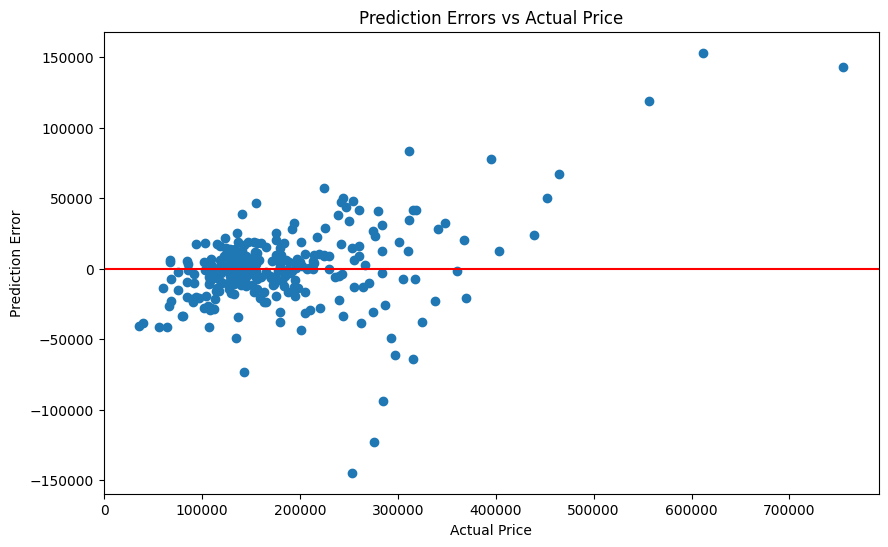

In [ ]:
y_pred_rf = models["XGBoost"].predict(X_test)
prediction_errors = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_rf,
    'Error': y_test - y_pred_rf
})

plt.figure(figsize=(10,6))
plt.scatter(prediction_errors['Actual'], prediction_errors['Error'])
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Actual Price')
plt.ylabel('Prediction Error')
plt.title('Prediction Errors vs Actual Price')
plt.show()

จากกราฟ Prediction Errors vs Actual Price สามารถวิเคราะห์ได้ดังนี้:

1. รูปแบบความผิดพลาดในการทำนาย:
- โมเดลมีแนวโน้มทำนายผิดพลาดมากขึ้นเมื่อราคาบ้านสูงขึ้น (ความแปรปรวนเพิ่มขึ้นตามราคา)
- บ้านราคาต่ำกว่า 200,000 มีความผิดพลาดในการทำนายน้อยกว่า (จุดกระจุกตัวแน่นใกล้เส้น 0)
- บ้านราคาสูง (400,000+) มักมีความผิดพลาดในการทำนายสูง

2. จุดที่น่าสนใจ:
- มีการทำนายผิดพลาดสูงสุดประมาณ +150,000 และ -150,000 ดอลลาร์
- บ้านในช่วงราคา 300,000 มีทั้งการประเมินราคาต่ำเกินและสูงเกินอย่างมีนัยสำคัญ
- มีจุด outliers หลายจุดในช่วงราคาสูง

3. ข้อเสนอแนะในการปรับปรุงโมเดล:
- ควรเพิ่มข้อมูลบ้านราคาสูงในการเทรนโมเดล
- อาจต้องทำ Feature Engineering เพิ่มเติมสำหรับบ้านราคาสูง
- พิจารณาใช้เทคนิค Weighted Sampling หรือแยกโมเดลสำหรับบ้านราคาสูง

4. ข้อเสนอแนะสำหรับการใช้งานโมเดล:
- ควรใช้โมเดลนี้ด้วยความระมัดระวังสำหรับบ้านราคาสูงกว่า 400,000
- การทำนายราคาบ้านในช่วง 100,000-200,000 มีความน่าเชื่อถือมากที่สุด
- ควรพิจารณาปัจจัยอื่นๆ ประกอบเสมอ โดยเฉพาะสำหรับบ้านราคาสูง

5. แนวทางการพัฒนาต่อ:
- เก็บข้อมูลเพิ่มเติมสำหรับบ้านราคาสูง
- สร้าง Feature ใหม่ที่อาจจะช่วยอธิบายความแตกต่างของราคาในบ้านระดับบน
- พิจารณาใช้เทคนิค Ensemble หรือ Stacking โดยเฉพาะสำหรับการทำนายบ้านราคาสูง